# CCN–CDNC susceptibility at cloud base, cloud maximum, and column level

**Scientific question.** How does the aerosol–cloud susceptibility
$\beta = \mathrm{d}\ln(\mathrm{CDNC}) / \mathrm{d}\ln(\mathrm{CCN})$ at each
observational station depend on *where in the cloud* CDNC and CCN are sampled —
at **cloud base**, at the **cloud maximum** (peak CDNC level), or
**vertically integrated over the column** — and how do these compare to the
all-level susceptibility?

For every station and every CCN cutoff radius we regress
$\log_{10}\mathrm{CDNC}$ on $\log_{10}\mathrm{CCN}$ using a **log-first,
equal-number-binned, median-per-bin** slope (the same recipe used in the global
and station susceptibility pipelines). The slope is the susceptibility; the
correlation `r` and standard error are carried alongside.

**Method note — order of operations (this is the corrected version).** The
earlier exploratory code binned CCN by *raw value*, averaged within each bin,
and only then took the log. That mixes a linear-space average into a
log-space slope. The correct order, applied here, is:

1. take $\log_{10}$ of both CCN and CDNC **first**;
2. form **equal-number** bins along $\log_{10}\mathrm{CCN}$ (sort and
   `np.array_split` into groups of equal count — robust to the skewed CCN
   distribution, no near-empty high-CCN bins);
3. take the **median** of each bin in both coordinates;
4. fit a straight line through the bin medians with `scipy.stats.linregress`.


## 1 · Setup and data

`NorESM_CCN_CDNC.nc` holds CCN (per cutoff radius) and CDNC on a
`(station, radius, time, lev)` grid. All configuration lives here.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats

import PeterChurchillFunctions as Function  # repo conventions / shared helpers

# ----------------------------------------------------------------------
# Configuration
# ----------------------------------------------------------------------
DATA_PATH = "/share/pech2273/NorESM_CCN_CDNC.nc"
N_BINS         = 100      # equal-number CCN bins
MIN_BIN_POINTS = 2        # minimum populated bins required for a fit
CI_Z           = 1.96     # z for 95% confidence band on the slope

Nor_CCN_CDNC_ds = xr.open_dataset(DATA_PATH)
CDNC_Nor = Nor_CCN_CDNC_ds.CDNC
CCN_Nor  = Nor_CCN_CDNC_ds.CCN

stations = Nor_CCN_CDNC_ds.station.values
radii    = Nor_CCN_CDNC_ds.radius.values
Nor_CCN_CDNC_ds

<xarray.Dataset> Size: 1GB
Dimensions:  (station: 15, radius: 31, time: 8761, lev: 32)
Coordinates:
  * time     (time) datetime64[ns] 70kB 2012-01-02 ... 2015-01-01
  * station  (station) <U8 480B 'ZEP' 'SMR-II' 'ATTO' ... 'Izana' 'Maldives'
  * lev      (lev) float64 256B 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * radius   (radius) float64 248B 1.0 1.23 1.514 1.862 ... 331.1 407.4 501.2
Data variables:
    CCN      (station, radius, time, lev) float64 1GB ...
    CDNC     (station, time, lev) float32 17MB ...

## 2 · Locate cloud base, cloud maximum, and column

Three vertical samplings of the same column:

- **Cloud base** — the lowest level (largest pressure) with non-zero CDNC. We
  reverse the `lev` axis so `argmax` along it returns the *first* cloudy level
  from the bottom, then map the index back to original numbering.
- **Cloud maximum** — the level of peak CDNC (NaN-safe `argmax` after filling
  NaNs with $-\infty$).
- **Column** — CDNC and CCN summed over `lev` (a vertically integrated proxy),
  so no level index is needed.

For cloud base and cloud max, the matching CCN is taken at the *same* level the
CDNC criterion selected.

In [2]:
# --- Cloud base: lowest level with non-zero CDNC --------------------------
da_rev = CDNC_Nor.isel(lev=slice(None, None, -1))   # reverse lev (bottom-up)
mask_nonzero = da_rev > 0
first_idx_rev = mask_nonzero.argmax(dim="lev")      # first cloudy level, reversed
has_cloud = mask_nonzero.any(dim="lev")             # columns with any cloud
first_idx_rev = first_idx_rev.where(has_cloud)
nlev = CDNC_Nor.sizes["lev"]
cloudbase_index = (nlev - 1) - first_idx_rev        # back to original numbering

# --- Cloud maximum: level of peak CDNC ------------------------------------
has_data = CDNC_Nor.notnull().any("lev")
cloudmax_index = CDNC_Nor.fillna(-np.inf).argmax("lev")
cloudmax_index = cloudmax_index.where(has_data)

In [3]:
# --- Sample CDNC/CCN at the selected levels -------------------------------
# .isel needs integer indices, so fill the NaN (no-cloud) entries with 0 for
# the gather and re-mask afterwards with .where(<index>.notnull()).

# Cloud base
cb_safe = cloudbase_index.fillna(0).astype(int)
cdnc_cloudbase = CDNC_Nor.isel(lev=cb_safe).where(cloudbase_index.notnull())
ccn_cloudbase  = CCN_Nor.isel(lev=cb_safe).where(cloudbase_index.notnull())

# Cloud maximum
cm_safe = cloudmax_index.fillna(0).astype(int)
cdnc_cloudmax = CDNC_Nor.isel(lev=cm_safe).where(cloudmax_index.notnull())
ccn_cloudmax  = CCN_Nor.isel(lev=cm_safe).where(cloudmax_index.notnull())

# Per-level cloud mask: True where that specific level has cloud (CDNC > 0)
cloud_levels = CDNC_Nor > 0

# Sum only over cloudy levels; CCN is gated by the SAME per-level mask so both
# fields see identical vertical support. Columns with no cloudy level -> NaN.
cdnc_column = CDNC_Nor.where(cloud_levels).sum("lev").where(has_cloud)
ccn_column  = CCN_Nor.where(cloud_levels).sum("lev").where(has_cloud)

### Sanity check — cloud base vs cloud max at one station

Cloud max should sit at or above cloud base, so CDNC at the max level should be
$\ge$ CDNC at base. A quick scatter at SGP confirms the sampled fields look
sensible on log axes.

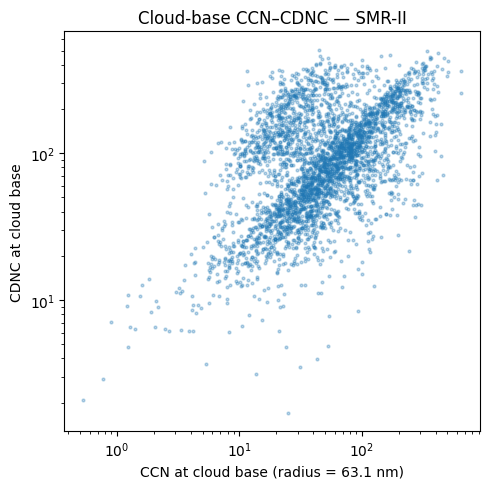

In [4]:
idx = 20
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(ccn_cloudbase.sel(station="SMR-II").isel(radius=idx),
           cdnc_cloudbase.sel(station="SMR-II"), s=4, alpha=0.3)
Radius = ccn_cloudbase.radius.isel(radius=idx).values
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(f'CCN at cloud base (radius = {Radius:.1f} nm)')
ax.set_ylabel("CDNC at cloud base")
ax.set_title("Cloud-base CCN–CDNC — SMR-II")
fig.tight_layout()
plt.show()

## 3 · Susceptibility helper (log-first, equal-number bins, median)

`susceptibility_by_station` runs the corrected slope for one `(CCN, CDNC)`
sampling across all stations and radii, returning a `(station, radius)` dataset
of `slope`, `r_value`, `std_err`, and `intercept`. The inner `_fit_logbinned`
encodes the four-step recipe; `binning='Equal Number'` is the robust default
(quantile-equivalent equal-count bins via sort + `array_split`).

In [5]:
def _fit_logbinned(ccn_vals, cdnc_vals, n_bins=N_BINS,
                   min_bins=MIN_BIN_POINTS, binning="Equal Number"):
    """Median-per-bin log10-log10 slope of CDNC vs CCN.

    Order of operations (the corrected version): log first, then bin in
    log-CCN, then take the per-bin median, then fit.

    Parameters
    ----------
    ccn_vals, cdnc_vals : numpy.ndarray
        1-D arrays (same length) of CCN and CDNC samples for one
        station/radius. Non-finite and non-positive entries are dropped.
    n_bins : int
        Number of CCN bins.
    min_bins : int
        Minimum populated bins required to attempt the linregress.
    binning : {'Equal Number', 'Equal Space'}
        'Equal Number' -> equal-count bins (sort + array_split, robust).
        'Equal Space'  -> equal-width bins in log10-CCN.

    Returns
    -------
    tuple or None
        (slope, intercept, r_value, std_err), or None if under-determined.
    """
    v = (np.isfinite(ccn_vals) & np.isfinite(cdnc_vals)
         & (ccn_vals > 0) & (cdnc_vals > 0))
    if v.sum() < 2:
        return None

    lx = np.log10(ccn_vals[v])      # log FIRST
    ly = np.log10(cdnc_vals[v])

    if binning == "Equal Number":
        # Equal-COUNT bins: sort by log-CCN, split into n_bins groups of equal
        # count, take each group's median. Robust to the skewed CCN range.
        order = np.argsort(lx)
        lx_s, ly_s = lx[order], ly[order]
        nb = min(n_bins, lx_s.size)             # can't have more bins than points
        lx_med = np.fromiter((np.median(g) for g in np.array_split(lx_s, nb)),
                             float, nb)
        ly_med = np.fromiter((np.median(g) for g in np.array_split(ly_s, nb)),
                             float, nb)
    else:
        # Equal-WIDTH bins in log10-CCN, median per bin.
        edges = np.linspace(lx.min(), lx.max(), n_bins + 1)
        idx = np.digitize(lx, edges)
        lx_med, ly_med = [], []
        for b in range(1, len(edges)):
            in_b = idx == b
            if in_b.any():
                lx_med.append(np.median(lx[in_b]))
                ly_med.append(np.median(ly[in_b]))
        lx_med, ly_med = np.array(lx_med), np.array(ly_med)

    finite = np.isfinite(lx_med) & np.isfinite(ly_med)
    if finite.sum() < min_bins:
        return None

    slope, intercept, r_value, _, std_err = stats.linregress(
        lx_med[finite], ly_med[finite])
    return slope, intercept, r_value, std_err


def susceptibility_by_station(ccn_da, cdnc_da, name=None):
    """Per-station, per-radius CCN-CDNC susceptibility for one vertical sampling.

    Parameters
    ----------
    ccn_da : xarray.DataArray
        CCN with dims including ('station', 'radius', <sample dim>).
    cdnc_da : xarray.DataArray
        CDNC with dims including ('station', <sample dim>). Broadcast against
        CCN across radius.
    name : str, optional
        Stored in the returned dataset's ``attrs['sampling']``.

    Returns
    -------
    xarray.Dataset
        Variables slope, r_value, std_err, intercept on (station, radius).
    """
    out = xr.Dataset(
        data_vars={
            k: (("station", "radius"),
                np.full((len(stations), len(radii)), np.nan))
            for k in ("slope", "r_value", "std_err", "intercept")
        },
        coords={"station": stations, "radius": radii},
    )

    for s, station in enumerate(stations):
        cdnc_vals = cdnc_da.sel(station=station).values.ravel()
        for r in range(len(radii)):
            ccn_vals = ccn_da.sel(station=station).isel(radius=r).values.ravel()
            fit = _fit_logbinned(ccn_vals, cdnc_vals)
            if fit is None:
                continue
            slope, intercept, r_value, std_err = fit
            out["slope"][s, r]     = slope
            out["intercept"][s, r] = intercept     # real intercept (not std_err)
            out["r_value"][s, r]   = r_value
            out["std_err"][s, r]   = std_err

    if name is not None:
        out.attrs["sampling"] = name
    return out

## 4 · Compute susceptibility for each sampling

Cloud base, cloud maximum, and column, all through the same corrected helper.
This is the expensive step (nested station × radius loops); run once and reuse.

In [6]:
reg_ds_cb     = susceptibility_by_station(ccn_cloudbase, cdnc_cloudbase, "cloud base")
reg_ds_cmax   = susceptibility_by_station(ccn_cloudmax,  cdnc_cloudmax,  "cloud max")
reg_ds_column = susceptibility_by_station(ccn_column,    cdnc_column,    "column")

# All-level susceptibility was computed elsewhere; load it for comparison.
reg_ds_all_lev = xr.open_dataset("/share/pech2273/NorESM_Susceptibility_All_level.nc")

Optionally persist the recomputed fields so downstream notebooks can load
them instead of recomputing.

In [7]:
# reg_ds_cb.to_netcdf("/share/pech2273/NorESM_CloudBase_Susceptibility.nc")
# reg_ds_cmax.to_netcdf("/share/pech2273/NorESM_CloudMax_Susceptibility.nc")
# reg_ds_column.to_netcdf("/share/pech2273/NorESM_Column_Susceptibility.nc")

## 5 · Per-station susceptibility spectra

### Figure 1 — All-level susceptibility, per-station grid

Susceptibility (with 95% band) and correlation `r` vs particle diameter
($D_p = 2r$) for every station, using the all-level reference field.

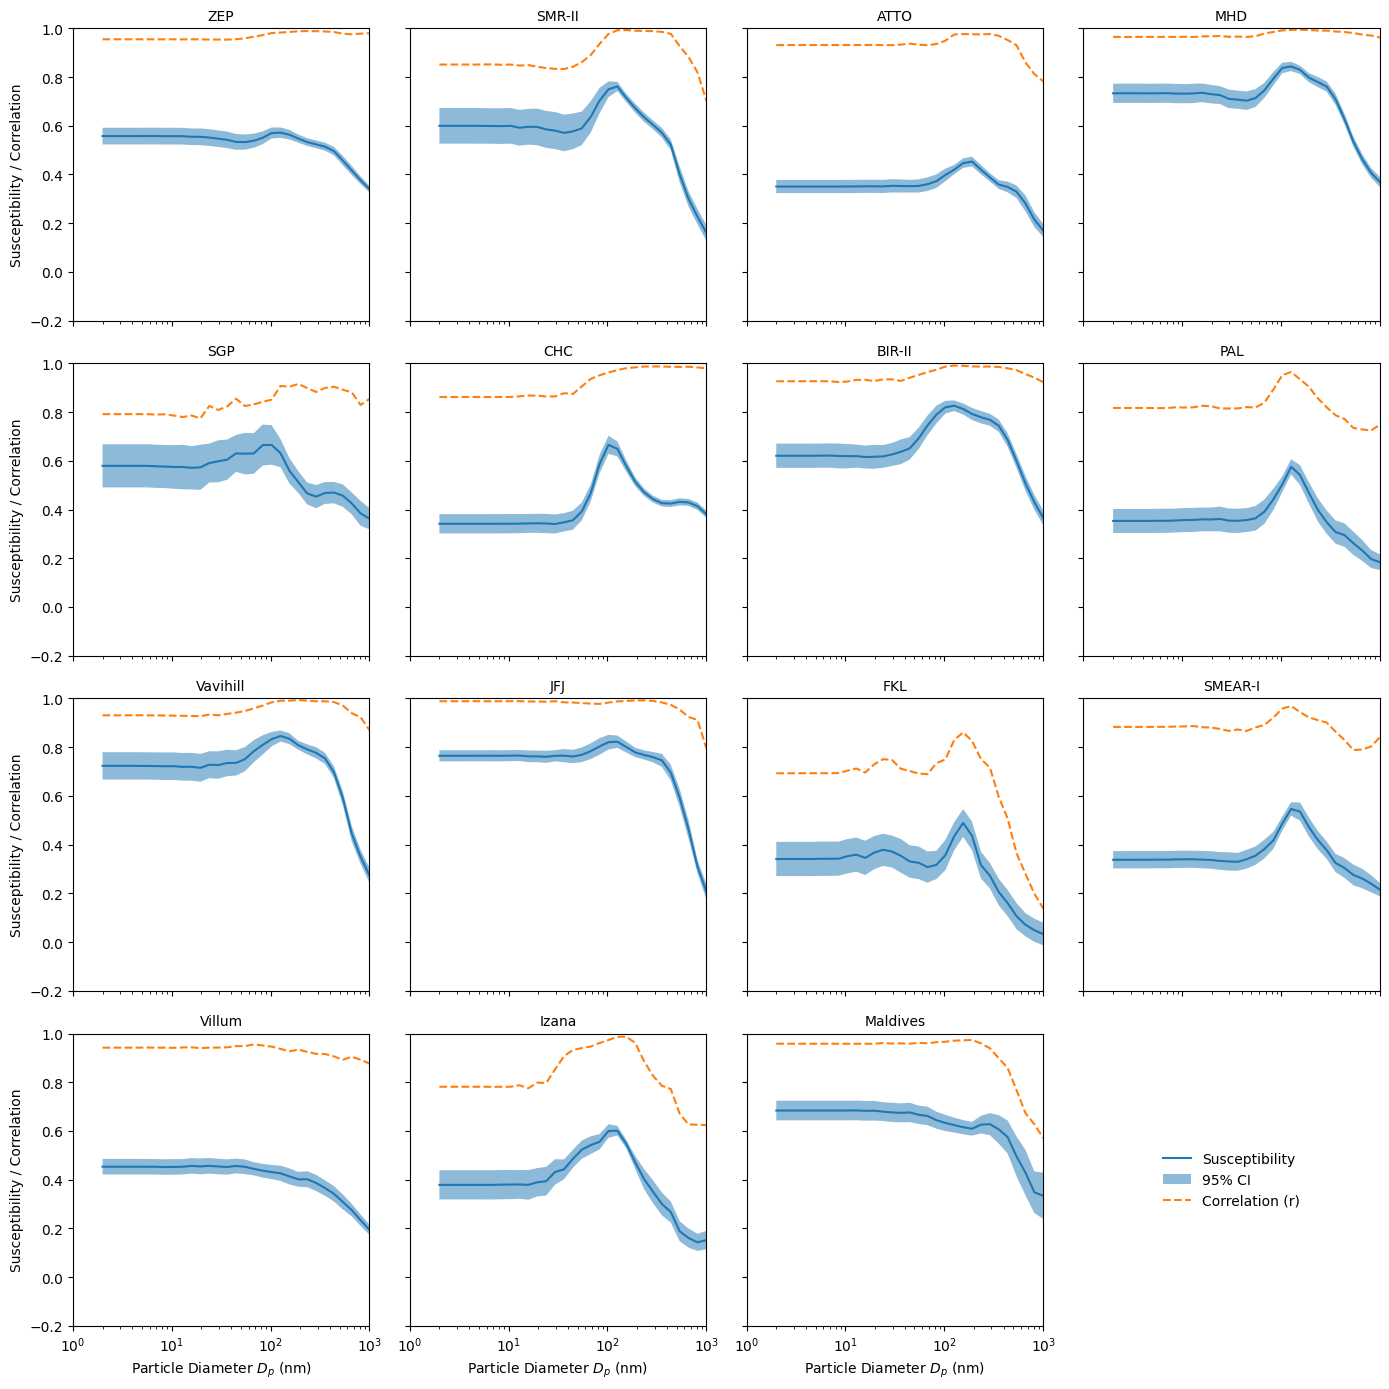

In [8]:
n_panel = len(stations)
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    slope   = reg_ds_all_lev["slope"].sel(station=station)
    std_err = reg_ds_all_lev["std_err"].sel(station=station)
    r_val   = reg_ds_all_lev["r_value"].sel(station=station)

    ax.plot(radii * 2, slope, label="Susceptibility")
    ax.fill_between(radii * 2, slope - CI_Z * std_err, slope + CI_Z * std_err,
                    alpha=0.5, label="95% CI")
    ax.plot(radii * 2, r_val, "--", label="Correlation (r)")
    ax.set_title(station, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# Use any trailing empty panel for a shared legend
for ax in axes[n_panel:]:
    ax.axis("off")
if n_panel < len(axes):
    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].legend(handles, labels, loc="center", frameon=False, fontsize=10)

for ax in axes[12:16]:
    ax.set_xlabel(r"Particle Diameter $D_p$ (nm)")
for ax in axes[::4]:
    ax.set_ylabel("Susceptibility / Correlation")
fig.tight_layout()
plt.show()

### Figure 2 — Sampling comparison at one station

Cloud base vs cloud max vs column vs all-level susceptibility at a single
station, each with its 95% band.

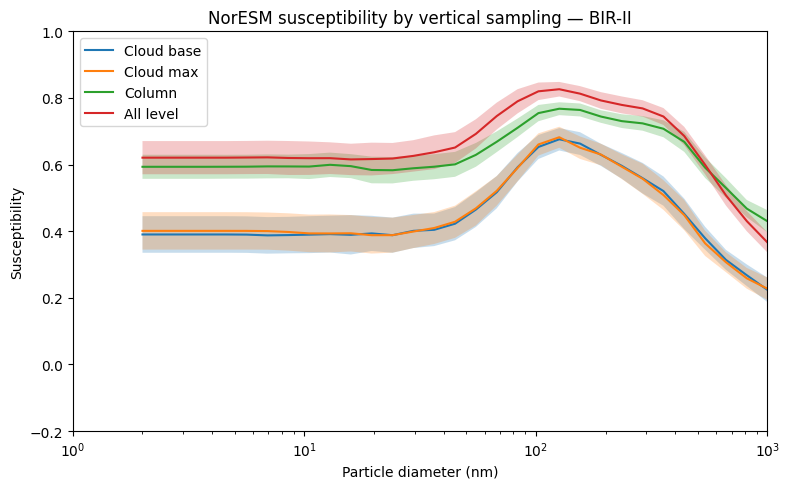

In [9]:
station = "BIR-II"
series = [
    (reg_ds_cb,      "Cloud base"),
    (reg_ds_cmax,    "Cloud max"),
    (reg_ds_column,  "Column"),
    (reg_ds_all_lev, "All level"),
]

fig, ax = plt.subplots(figsize=(8, 5))
for d, label in series:
    sl = d["slope"].sel(station=station)
    se = d["std_err"].sel(station=station)
    ax.plot(radii * 2, sl, label=label)
    ax.fill_between(radii * 2, sl - CI_Z * se, sl + CI_Z * se, alpha=0.25)
ax.set_xscale("log")
ax.set_xlim([1, 1000])
ax.set_ylim([-0.2, 1])
ax.set_xlabel("Particle diameter (nm)")
ax.set_ylabel("Susceptibility")
ax.set_title(f"NorESM susceptibility by vertical sampling — {station}")
ax.legend()
fig.tight_layout()
plt.show()

### Figure 3 — Sampling comparison, mean over stations

The same four samplings averaged across stations, giving the ensemble
susceptibility spectrum for each vertical sampling.

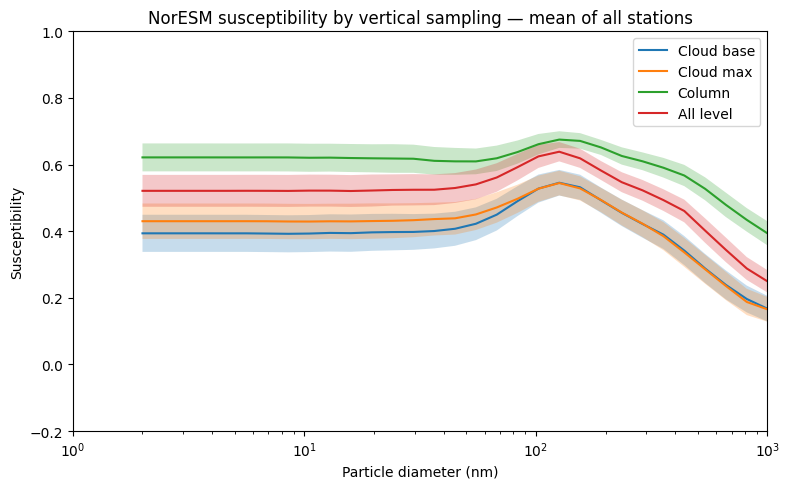

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
for d, label in series:
    sl = d["slope"].mean("station")
    se = d["std_err"].mean("station")
    ax.plot(radii * 2, sl, label=label)
    ax.fill_between(radii * 2, sl - CI_Z * se, sl + CI_Z * se, alpha=0.25)
ax.set_xscale("log")
ax.set_xlim([1, 1000])
ax.set_ylim([-0.2, 1])
ax.set_xlabel("Particle diameter (nm)")
ax.set_ylabel("Susceptibility")
ax.set_title("NorESM susceptibility by vertical sampling — mean of all stations")
ax.legend()
fig.tight_layout()
plt.show()

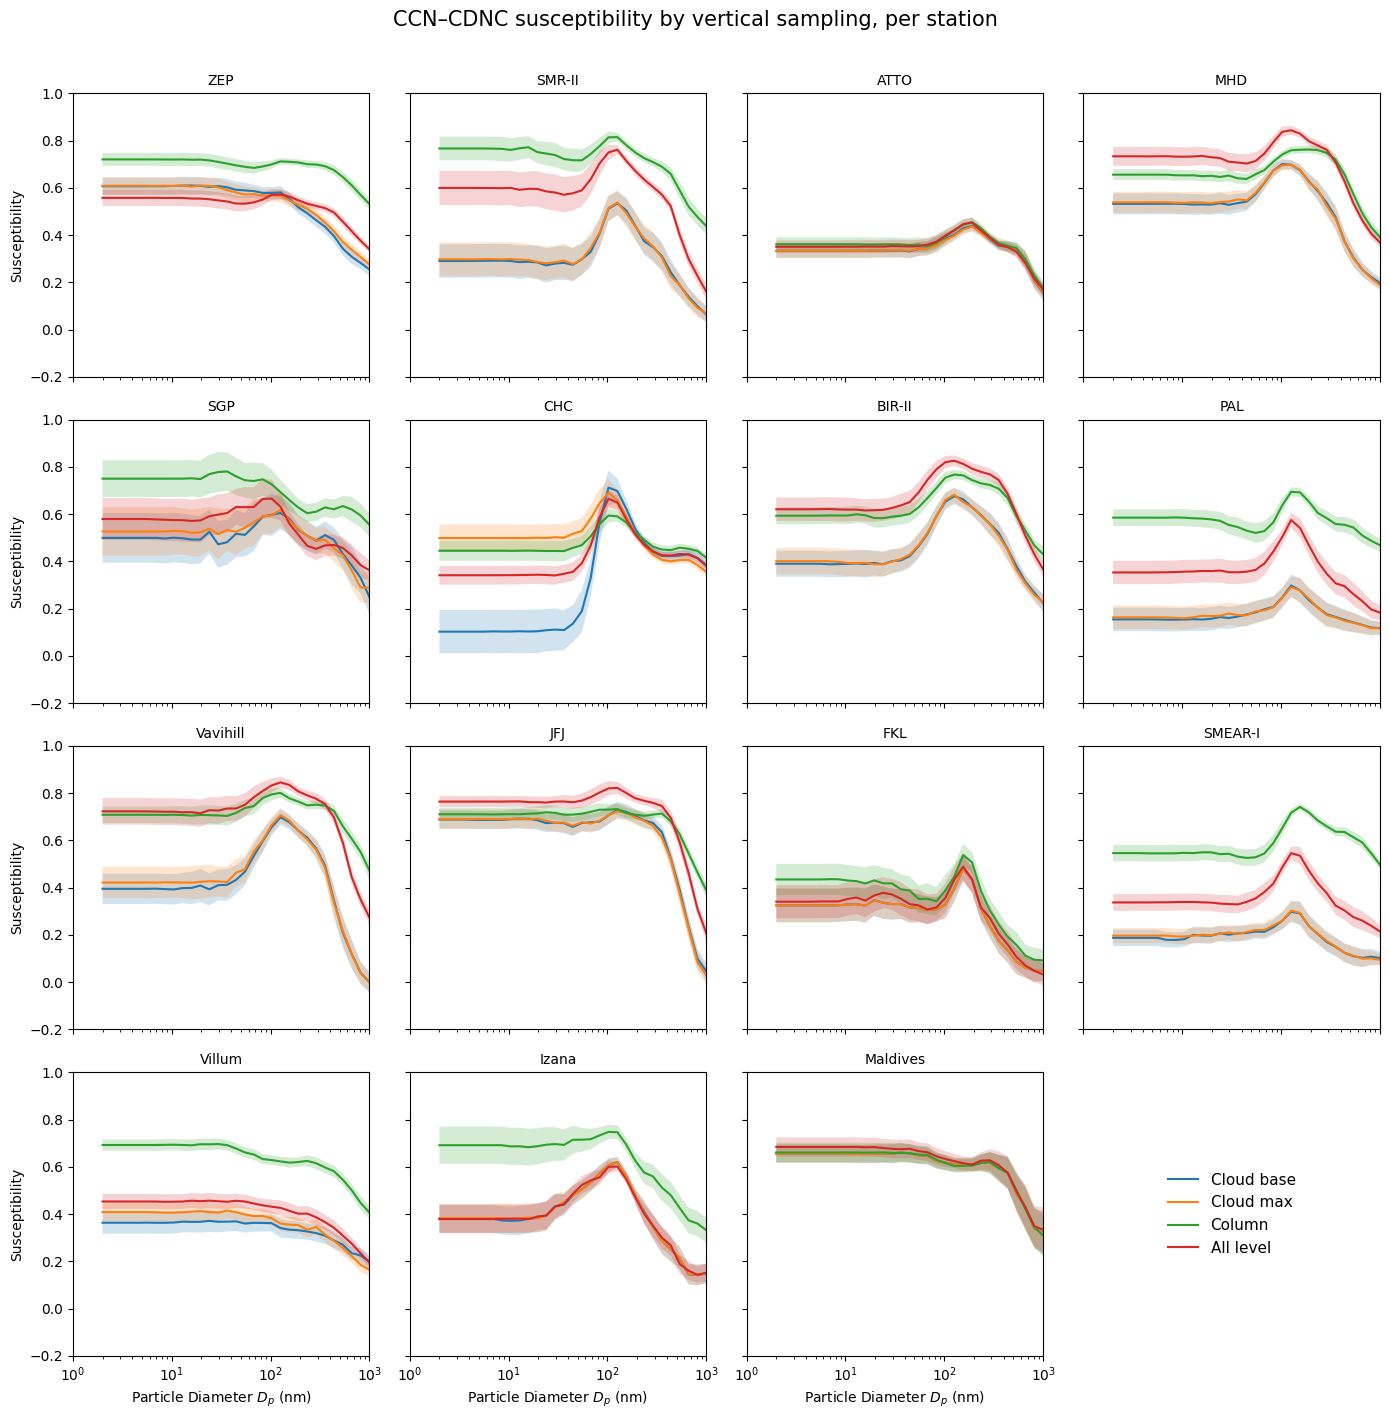

In [11]:
series = [
    (reg_ds_cb,      "Cloud base"),
    (reg_ds_cmax,    "Cloud max"),
    (reg_ds_column,  "Column"),
    (reg_ds_all_lev, "All level"),
]

n_panel = len(stations)
fig, axes = plt.subplots(4, 4, figsize=(14, 14), sharex=True, sharey=True)
axes = axes.flatten()

for i, station in enumerate(stations):
    ax = axes[i]
    for d, label in series:
        sl = d["slope"].sel(station=station)
        se = d["std_err"].sel(station=station)
        ax.plot(radii * 2, sl, label=label)
        ax.fill_between(radii * 2, sl - CI_Z * se, sl + CI_Z * se, alpha=0.20)
    ax.set_title(station, fontsize=10)
    ax.set_xscale("log")
    ax.set_xlim([1, 1000])
    ax.set_ylim([-0.2, 1])

# Trailing empty panel(s) -> shared legend
for ax in axes[n_panel:]:
    ax.axis("off")
if n_panel < len(axes):
    handles, labels = axes[0].get_legend_handles_labels()
    axes[-1].legend(handles, labels, loc="center", frameon=False, fontsize=11)

for ax in axes[12:16]:
    ax.set_xlabel(r"Particle Diameter $D_p$ (nm)")
for ax in axes[::4]:
    ax.set_ylabel("Susceptibility")
fig.suptitle("CCN–CDNC susceptibility by vertical sampling, per station",
             y=1.01, fontsize=15)
fig.tight_layout()
plt.show()